In [1]:
from util.DataGen import *
from util.Plotting import *
from util.Processing import *
from util.metrics import *
from scipy.linalg import circulant
from scipy.optimize import nnls, lsq_linear
from scipy.signal import find_peaks

import numpy as np
import matplotlib.pyplot as plt


250.0 Photons
mV_per_keV 0.12907739940993107
(2001,) (2001,) (250,) (250,)


Text(0.5, 0, 'Time Index')

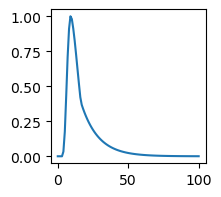

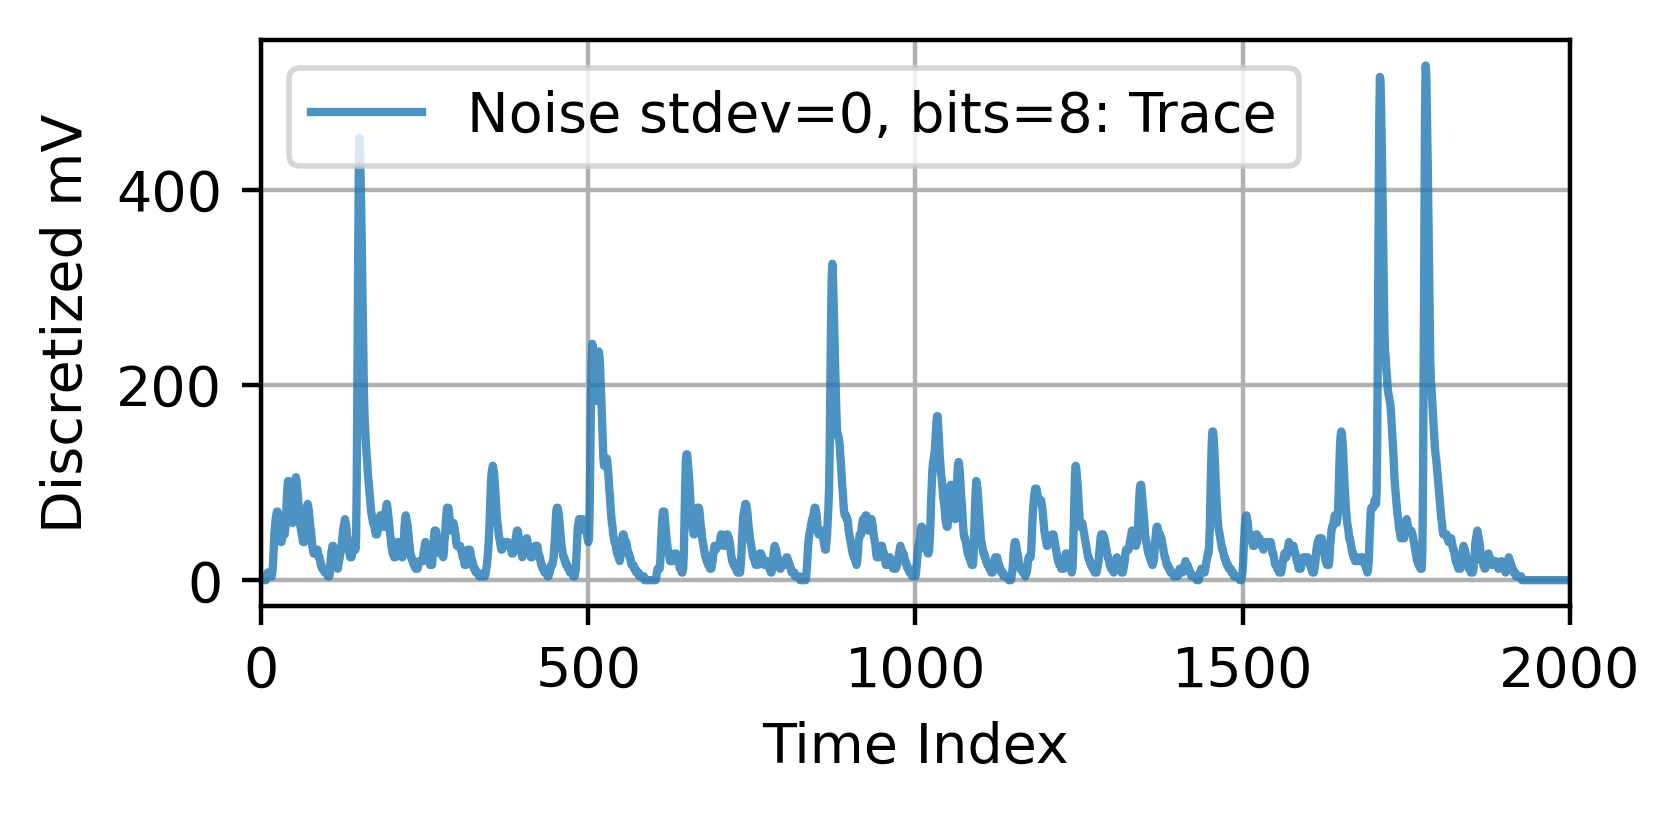

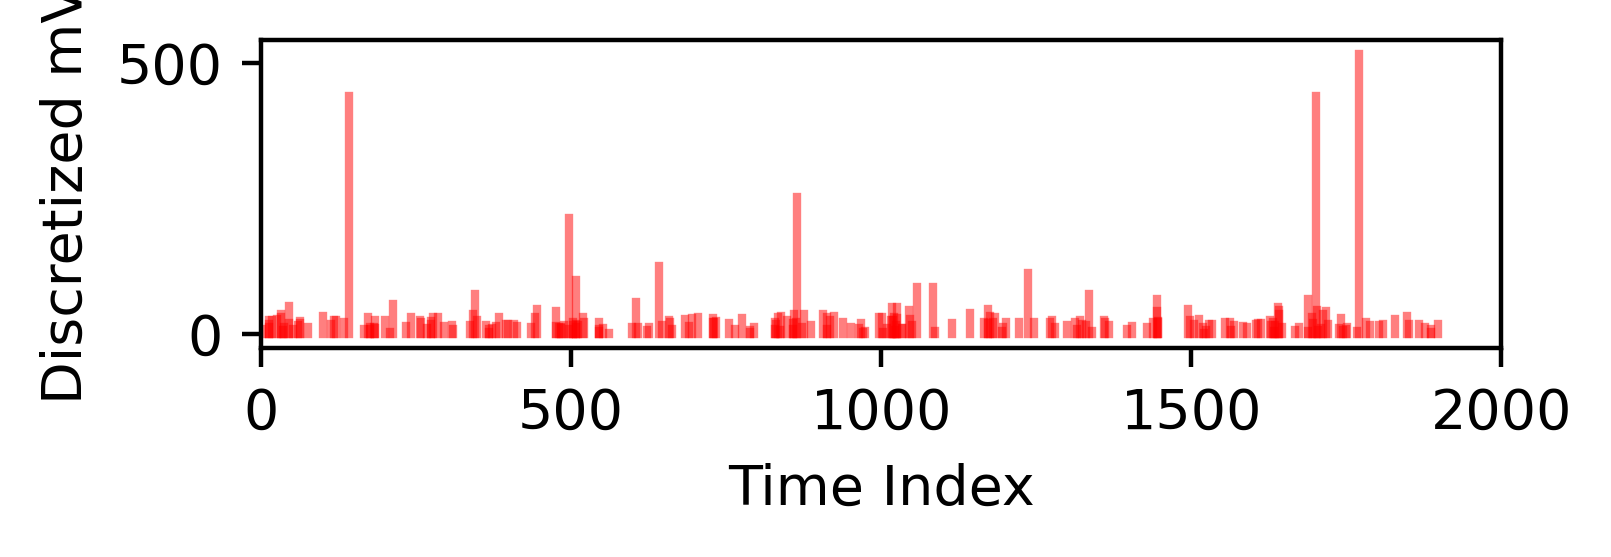

In [3]:
# Trace
sensor_type = 'NaI'
seed = 3
countrate = 5e6
total_time = 5e-5
noise_stdev = 0 # mV
bits = 8 # 8 bits is

repeat = 10

print('{} Photons'.format(countrate * total_time) )

dt = np.float64(25e-9) #sampling rate in seconds. 40MHz
sampling_ratio = 1

assert sensor_type in ['plastic', 'NaI']
if sensor_type == 'plastic':
	_, decimal_kernel = plastic_pulse(1)
	spectrum = np.loadtxt('../original/LgPl_Response',usecols=(1), dtype=float)
	bins = 1E3 * np.loadtxt('../original/LgPl_Response',usecols=(0), dtype=float) # in kev
else:
	_, decimal_kernel = nai_pulse(1, 101, sampling_ratio)
	spectrum = np.loadtxt('../original/NaI_Response',usecols=(1), dtype=float)
	bins = 1E3 * np.loadtxt('../original/NaI_Response',usecols=(0), dtype=float) # in kev

plt.figure(figsize=(2, 2))
plt.plot(decimal_kernel)

keV_per_area = .147 #determined by trial and error to match energy range of instrument 
mV_per_ADC = 1000./4096.
area_per_peak = np.sum(decimal_kernel)/max(decimal_kernel)
mV_per_keV = mV_per_ADC/(keV_per_area*area_per_peak)
print('mV_per_keV', mV_per_keV)


#########################################################################################################################
# Spectrum trace
trace, time_vector, volts_list, volts_time_index = spectrum_trace(
                                                    count_rate_=countrate, dt_=dt, total_time_=total_time,
                                                    pulse_=decimal_kernel, bin_energies_=bins, spectrum_=spectrum,
                                                    mV_per_keV_=mV_per_keV, noise_std_=noise_stdev, baseline_=0,
                                                    sampling_ratio_=sampling_ratio, discretize=True, bits_=bits,
                                                    seed_=seed, clip=False, debug=False)

print(
    trace.shape,
    time_vector.shape,
    volts_list.shape,
    volts_time_index.shape,
)

##########################################################################################################################
    
N = trace.size
trace_fft_noise = trace

fig, axes = plt.subplots(1, 1, figsize=(4, 2), dpi=400)
fig.tight_layout()
axes.plot(trace_fft_noise, label='Noise stdev={}, bits={}: Trace'.format(noise_stdev, bits), alpha=.8)
xlim = [0, 2000]
axes.set_xlim(xlim)
axes.legend(loc=1)
axes.set_ylabel('Discretized mV')
axes.set_xlabel('Time Index')
axes.grid()
axes.legend()

fig, axes = plt.subplots(1, 1, figsize=(4, 1), dpi=400)
plot_photons(axes, volts_time_index, volts_list, label_='{} Photons'.format(len(volts_list)), color='r', alpha=.5)
axes.set_xlim(xlim)
axes.set_ylabel('Discretized mV')
axes.set_xlabel('Time Index')


[0.         0.         7.11491212 ... 0.         0.         0.        ]


Text(0.5, 1.0, 'Scipy Non Negative LSR')

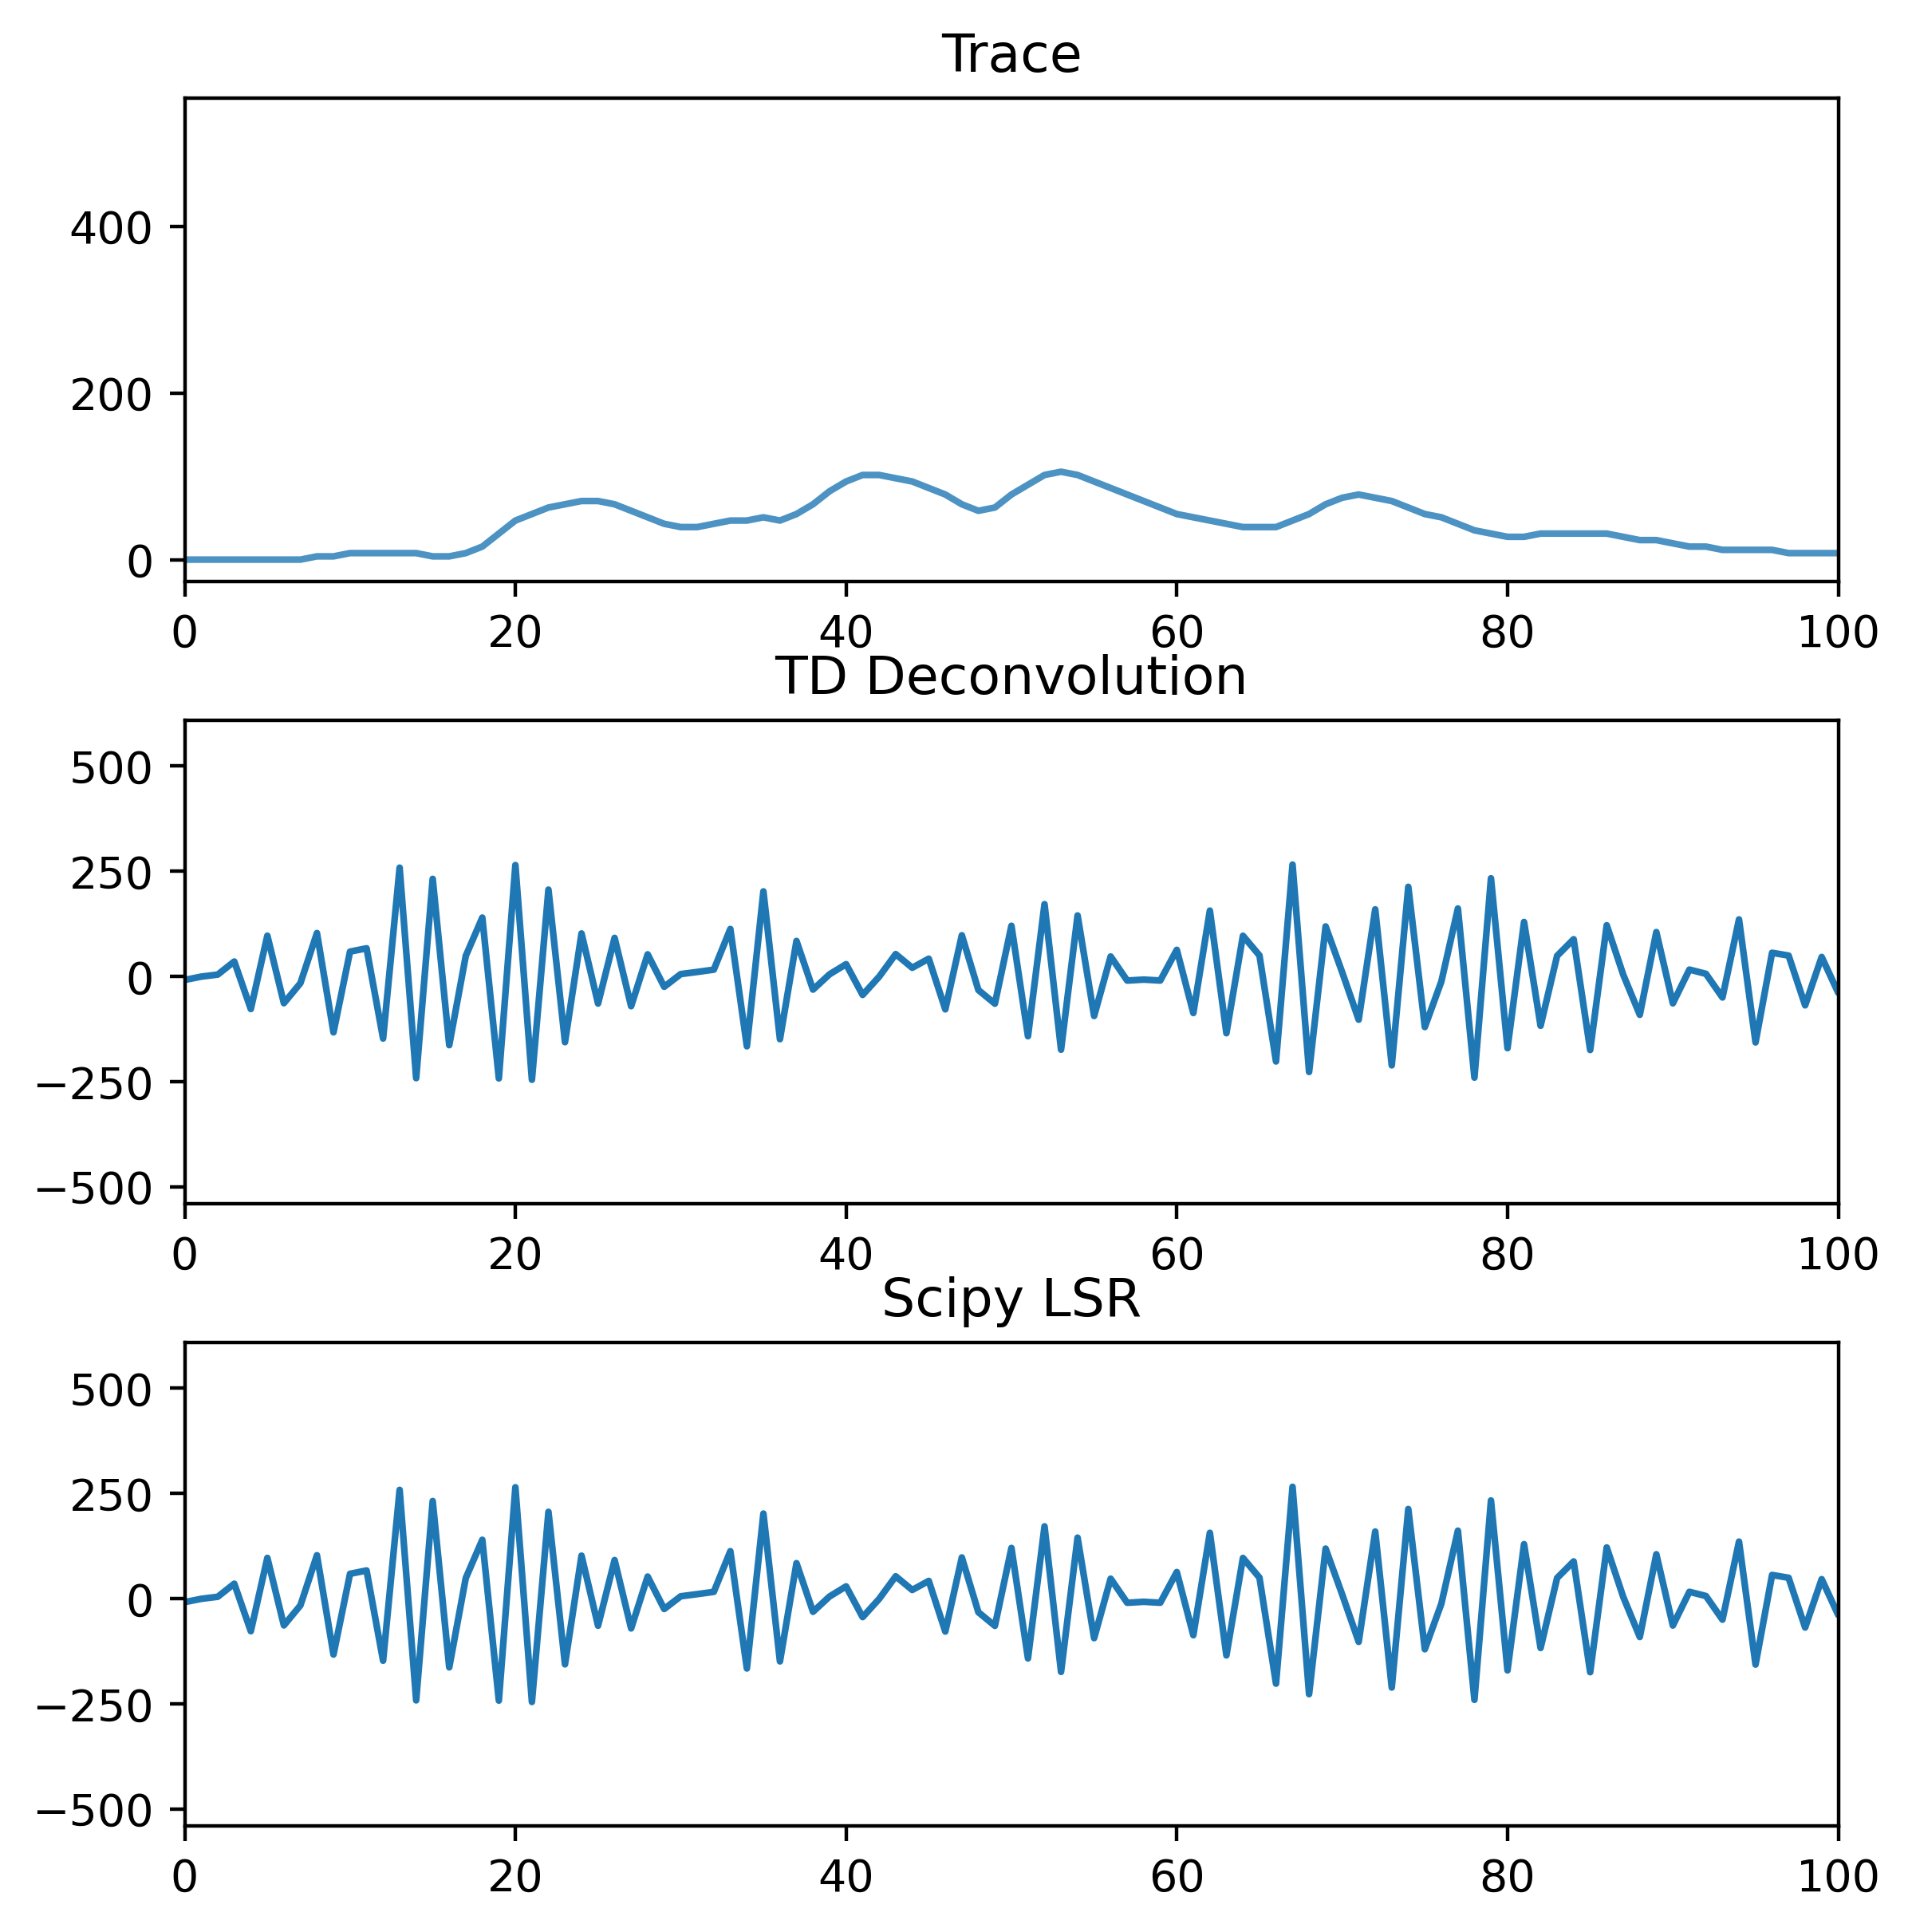

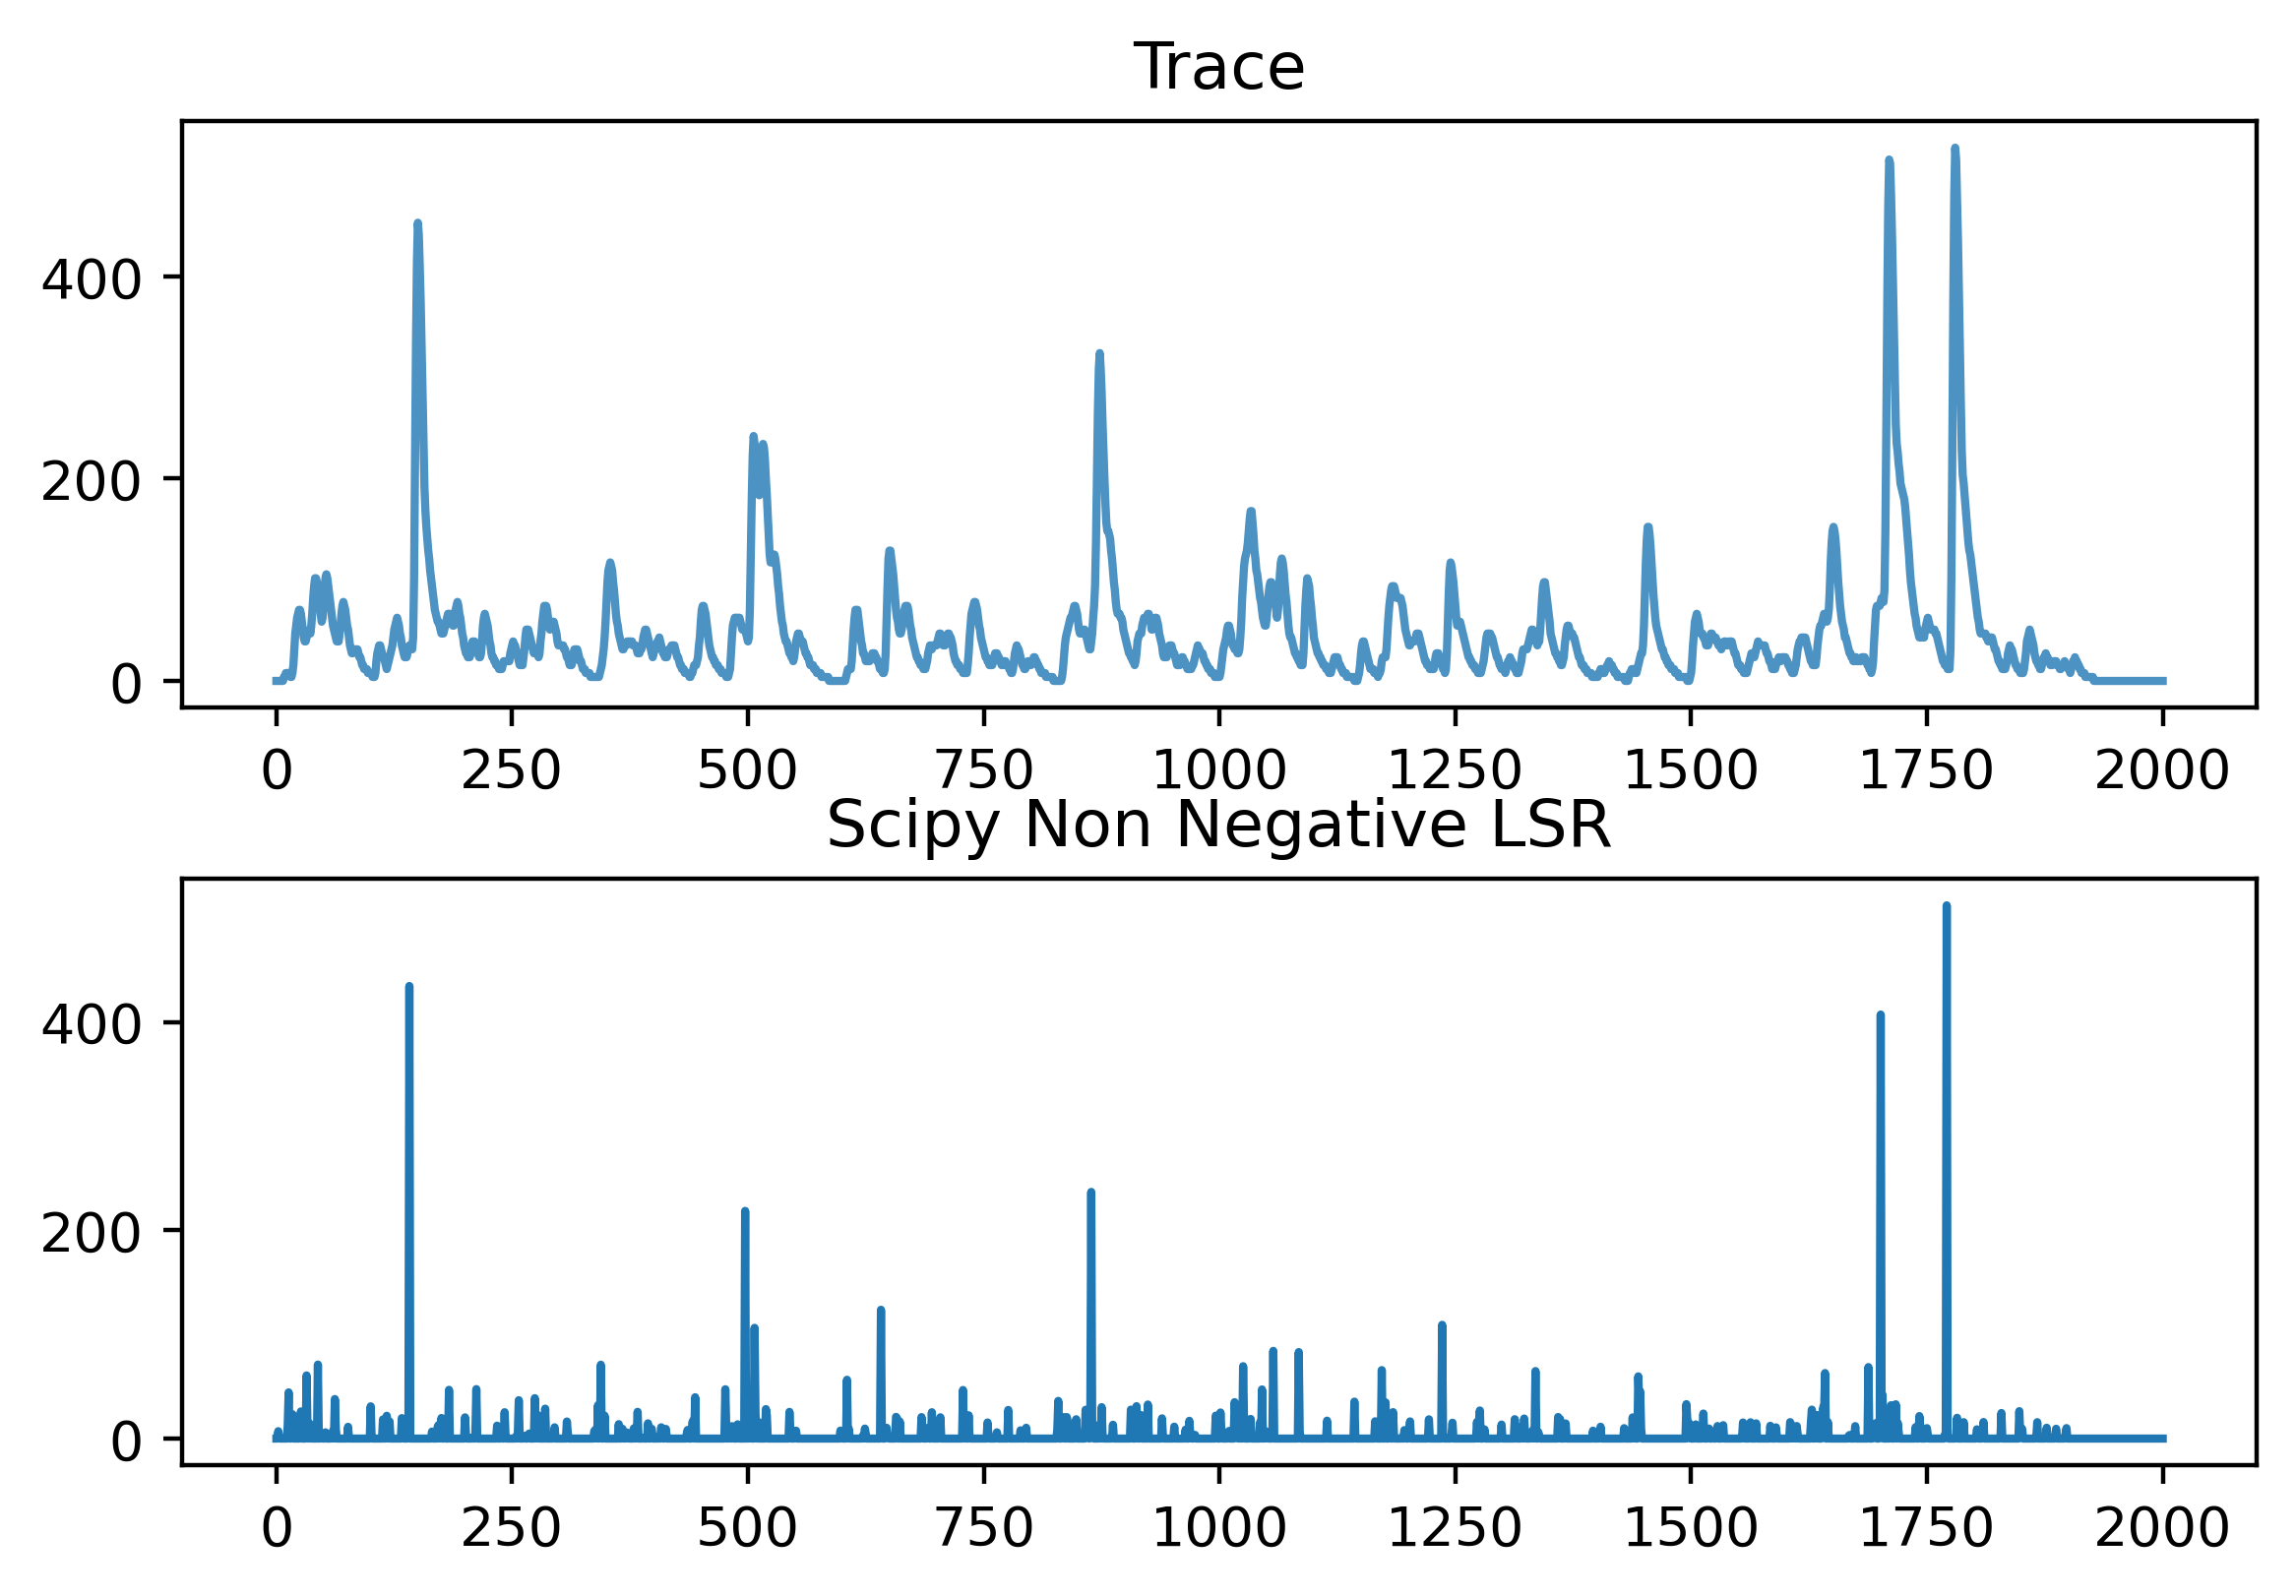

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(6, 6), dpi=400)
fig.tight_layout()
axes[0].plot(trace_fft_noise, label='Noise stdev={}, bits={}: Trace'.format(noise_stdev, bits), alpha=.8)
axes[0].set_title('Trace')
axes[0].set_xlim([0, 100])

# Old TD Deconvolution...
_, kernel = nai_pulse(1, 101, sampling_ratio)
x = td_deconvolve(trace, kernel)
axes[1].plot(x)
axes[1].set_title('TD Deconvolution')
axes[1].set_xlim([0, 100])

# Scipy non negative Least squares
# argmin_x || Ax - b ||_2    <-  Y=Ax (Y=Trace=b, x=photon_magnitudes)
y = trace_fft_noise
A = circulant(np.concatenate((kernel, np.zeros(y.size - kernel.size)), axis=0))
x = lsq_linear(A, y)
axes[2].plot(x.x)
axes[2].set_title('Scipy LSR')
axes[2].set_xlim([0, 100])


fig, axes = plt.subplots(2, 1, figsize=(6, 4), dpi=400)
fig.tight_layout()
axes[0].plot(trace_fft_noise, label='Noise stdev={}, bits={}: Trace'.format(noise_stdev, bits), alpha=.8)
axes[0].set_title('Trace')

# x, resid = nnls(A, y)
x = td_nnlsr_deconvolve(y, kernel)
print(x)
axes[1].plot(x)
axes[1].set_title('Scipy Non Negative LSR')



Stats
Count rate: 5.00E+06, time: 5.00E-05, bits: 8, Noise stdev: 0
Coincident Photons: 7.60%, Coincident Energy: 13.79732%

LSR Detection:
True Photons: 250 Detected Photons: 339
Counted Photons: 135.60%, Counted Energy: 96.19555%


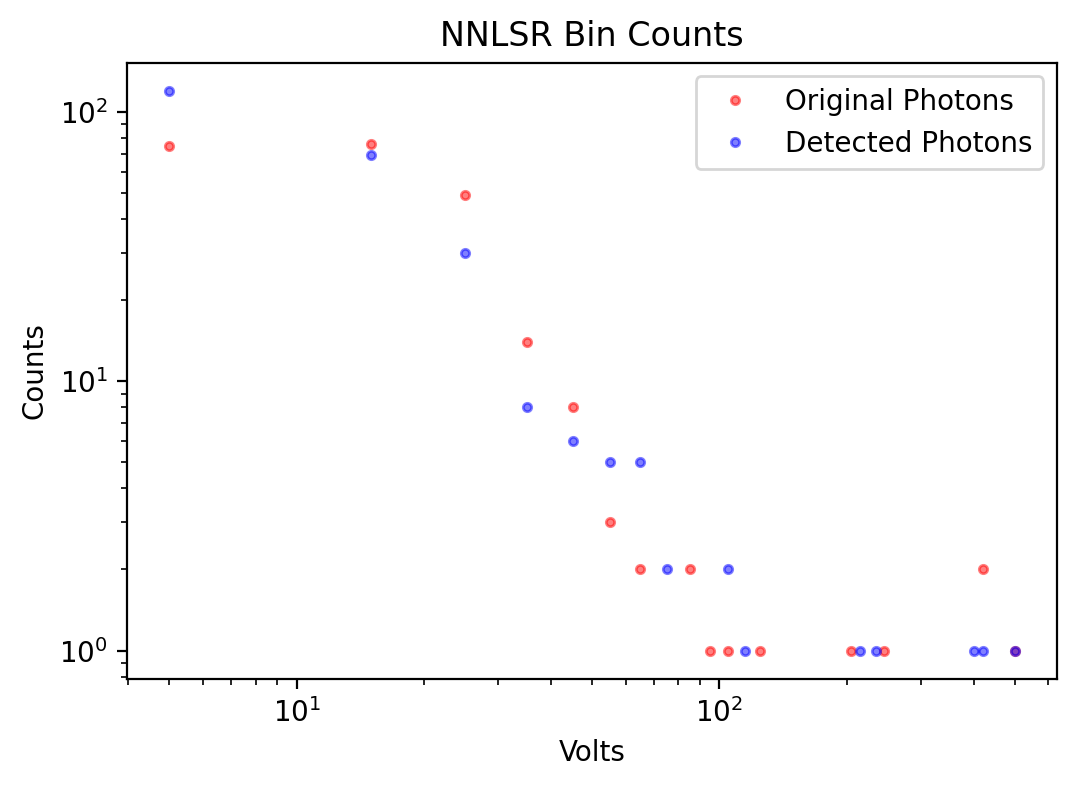

In [5]:
#Stats
print('Stats')
print("Count rate: {:.2E}, time: {:.2E}, bits: {}, Noise stdev: {}".format(countrate, total_time, bits, noise_stdev))

coincident_photons_pct, coincident_energy_pct = coincident_pct(volts_time_index, volts_list, time_vector)
print("Coincident Photons: {:.2f}%, Coincident Energy: {:.5f}%".format(coincident_photons_pct*100, coincident_energy_pct*100))


# Summed volts list values
summed_index_list, summed_volts_list = summed_listmode(volts_time_index, volts_list, time_vector)

# Detect Photons...
print('\nLSR Detection:')
threshold = 1 # mV
thresholded_volts_list, thresholded_indeces = threshold_listmode(x, threshold)
print('True Photons:', volts_list.size, 'Detected Photons:', thresholded_volts_list.size)

photons_counted = photons_counted_pct(thresholded_indeces, volts_time_index)
energy_counted = volts_counted_pct(thresholded_volts_list, volts_list)
print("Counted Photons: {:.2f}%, Counted Energy: {:.5f}%".format(photons_counted*100, energy_counted*100))

#TODO this comparison is not right until the magnitude of the deconvolution is fixed...
# Histograms by Magnitude
original_counts, original_values, counted_counts, counted_values = volts_counted_hist(volts_list, thresholded_volts_list, bins=bins)

plt.figure(figsize=(6,4), dpi=200)
original_gt0 = np.where(original_counts > 0)[0]
counted_gt0 = np.where(counted_counts > 0)[0]
plt.plot(bins[:-1][original_gt0], original_counts[original_gt0], label='Original Photons', linestyle='', marker='.', color='r', alpha =.5)
plt.plot(bins[:-1][counted_gt0], counted_counts[counted_gt0], label='Detected Photons', linestyle='', marker='.', color='b', alpha =.5)

# plt.xlim([0, 300])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Volts')
plt.ylabel('Counts')
plt.title('NNLSR Bin Counts')
plt.legend()

# FPGA Algo Detection




(471,)
Stats
Count rate: 5.00E+06, time: 5.00E-05, bits: 8, Noise stdev: 0, K: 0.1
Coincident Photons: 7.60%, Coincident Energy: 13.79732%

Detection:
True Photons: 250 Detected Photons: 627
Counted Photons: 250.80%, Counted Energy: 317.57986%


(0.0, 2.0)

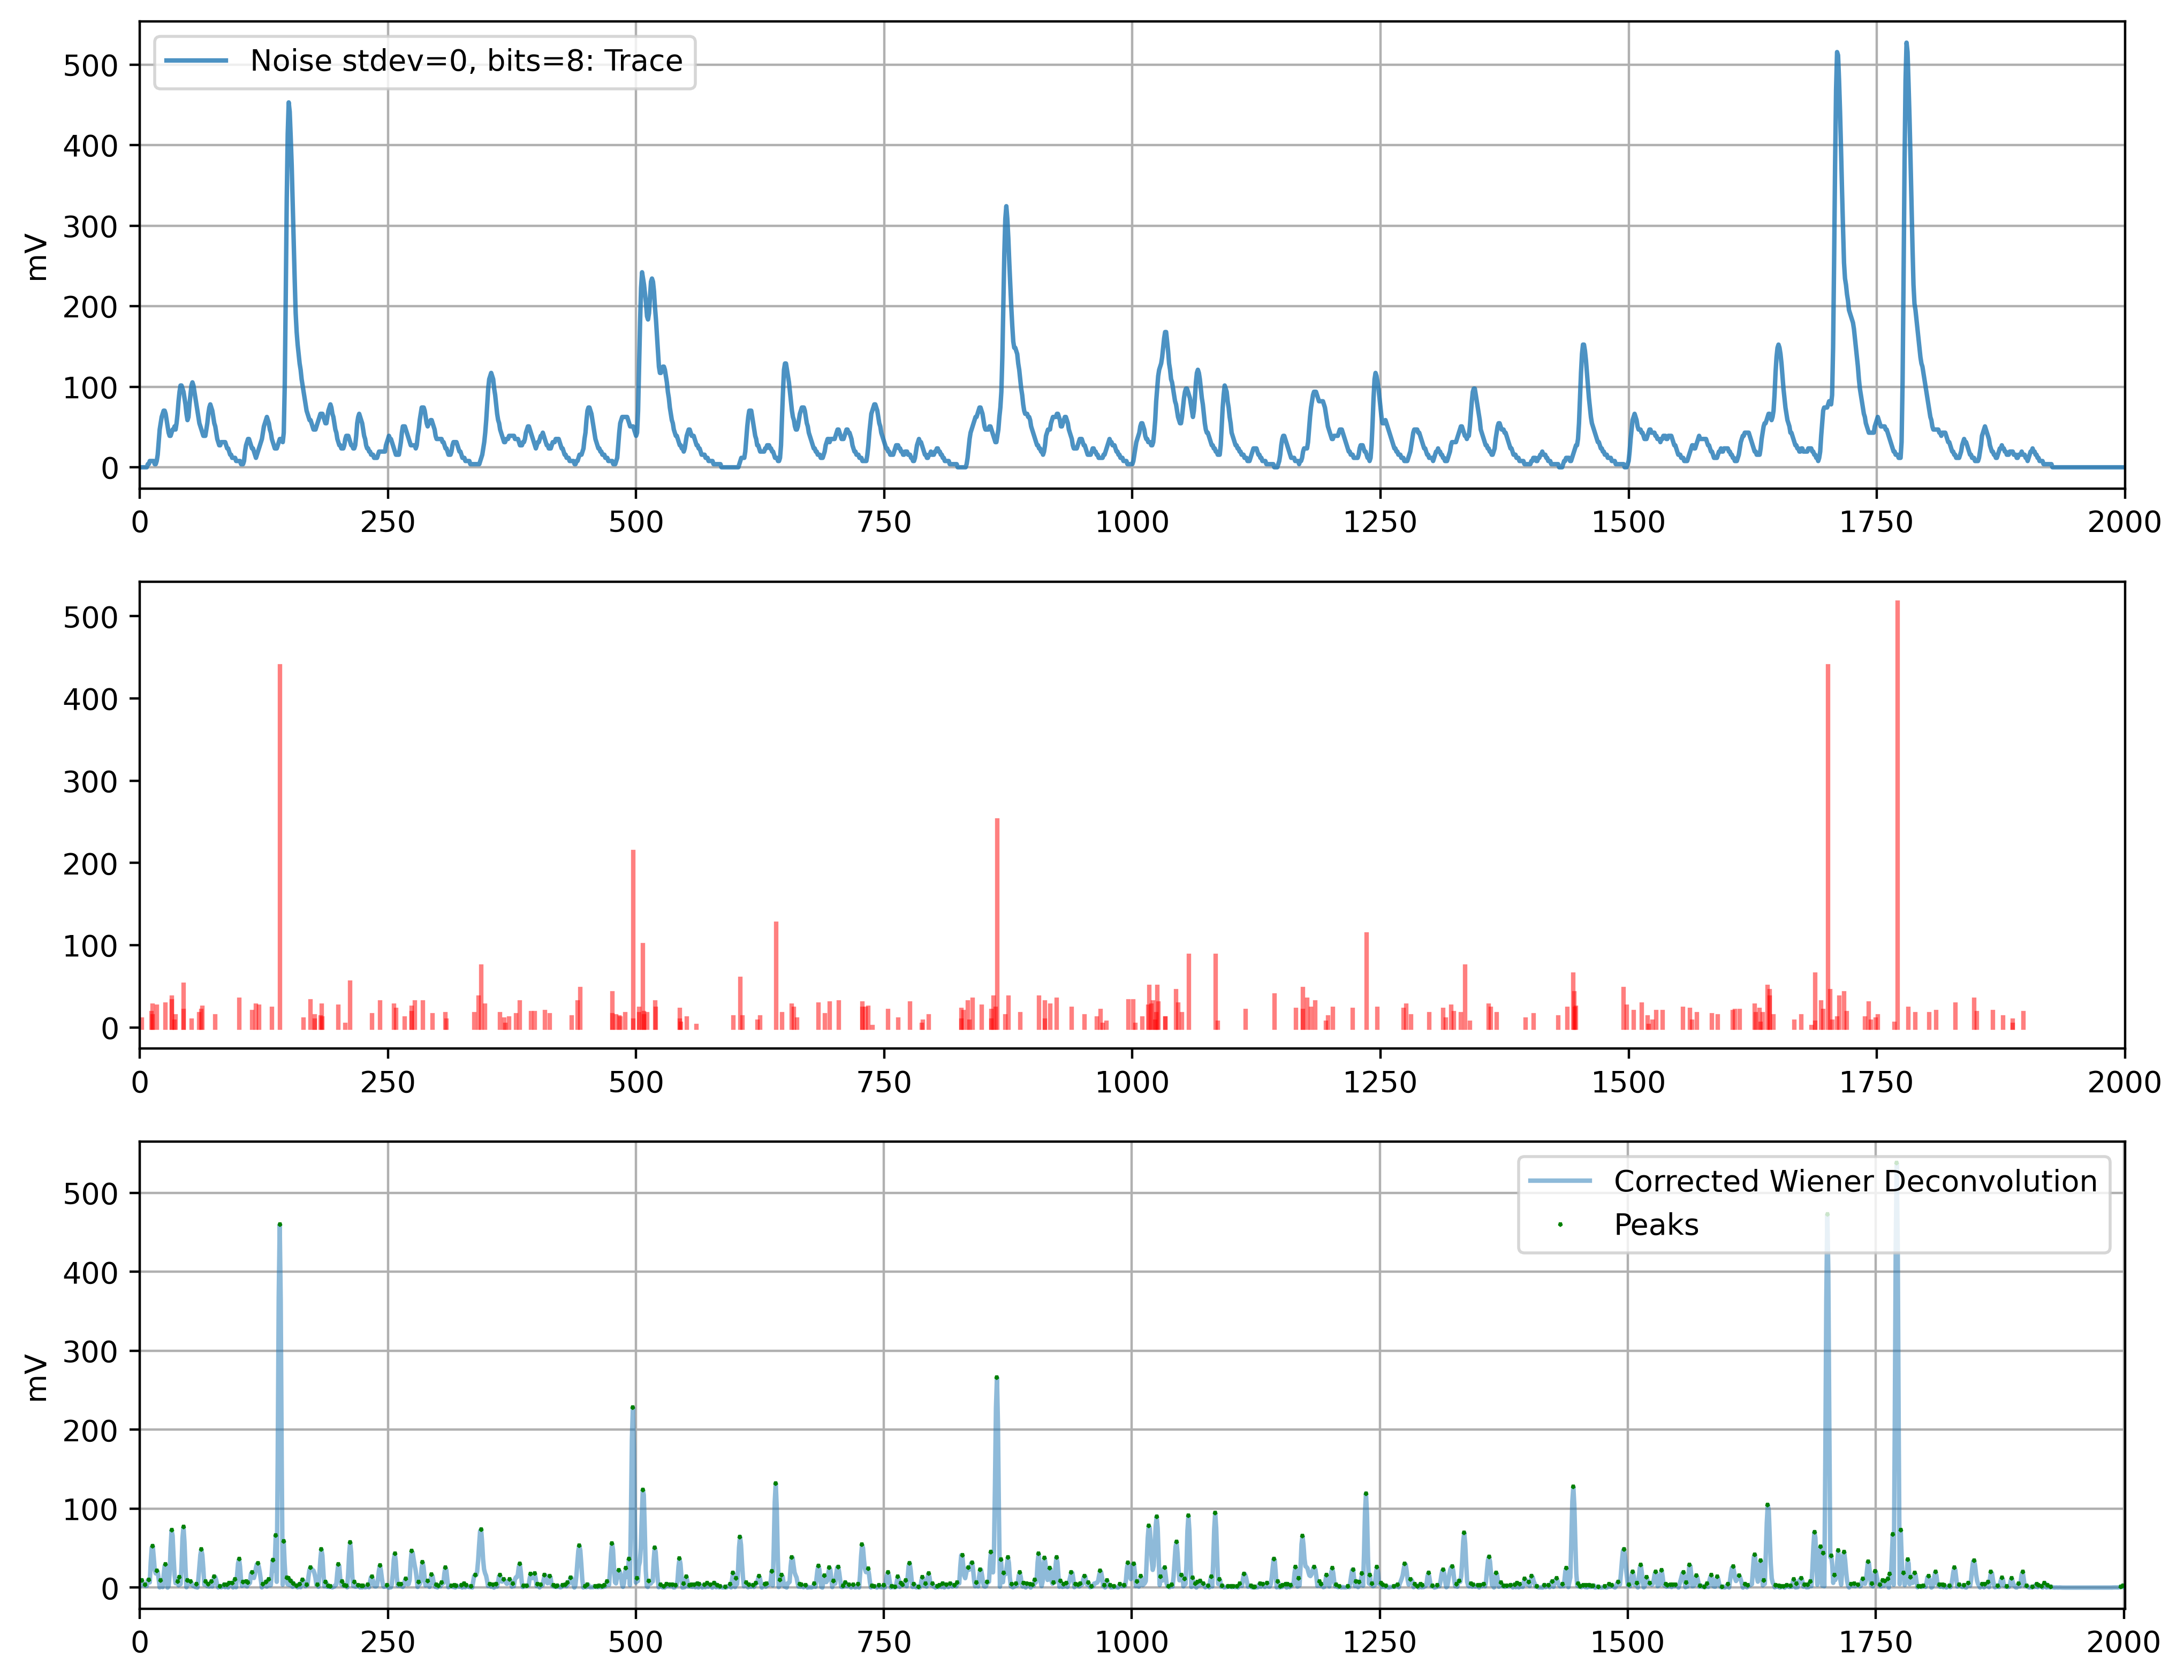

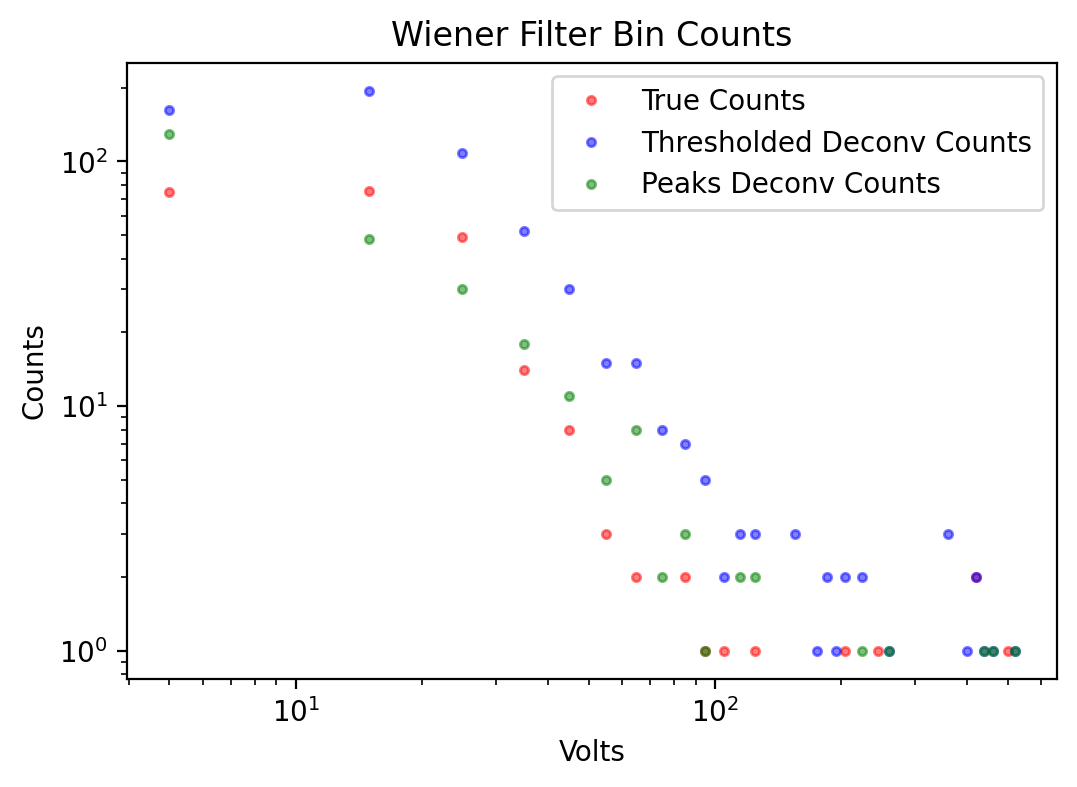

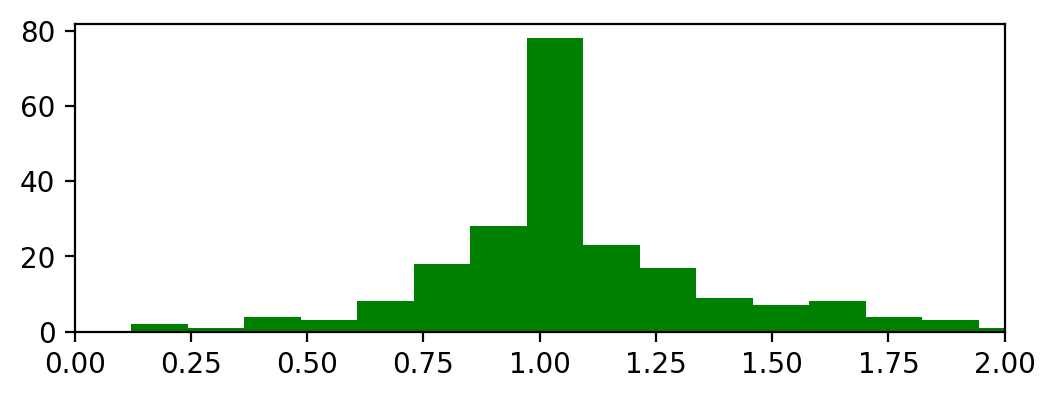

In [6]:
# Wiener Deconv

# PARAM ############################################################################3
K = 1e-1
# correction_factor = 1
correction_factor = 1 / .32 # needs to be set with K! Set to 1 for small K!
wiener_threshold = 10
# PARAM ############################################################################3

fig, axes = plt.subplots(3, 1, figsize=(10, 8), dpi=400)
fig.tight_layout()
axes[0].plot(trace_fft_noise, label='Noise stdev={}, bits={}: Trace'.format(noise_stdev, bits), alpha=.8)
xlim = [0, 2000]
axes[0].set_xlim(xlim)
axes[0].legend(loc=1)
axes[0].set_ylabel('mV')
axes[0].grid()
axes[0].legend()

plot_photons(axes[1], volts_time_index, volts_list, label_='{} Photons'.format(len(volts_list)), color='r', alpha=.5)
axes[1].set_xlim(xlim)

wiener_deconv_noise_quantized = wiener_deconvolve(trace_fft_noise, kernel, K) * correction_factor

# plot_photons(axes[1], volts_time_indeces, volts_list, label_='{} Photons'.format(len(volts_list)), color='r', alpha=.5)
axes[2].plot(wiener_deconv_noise_quantized, label='Corrected Wiener Deconvolution', alpha=.5)
# axes[1].set_ylim([0, np.max(trace)])

peaks, _ = find_peaks(wiener_deconv_noise_quantized, height=threshold)
print(peaks.shape)
peak_vals = wiener_deconv_noise_quantized[peaks]
axes[2].plot(peaks, peak_vals, 'g*', markersize='1', label='Peaks')

axes[2].set_xlim([0, N])
axes[2].legend(loc=1)
axes[2].set_ylabel('mV')
axes[2].grid()

#Stats
print('Stats')
print("Count rate: {:.2E}, time: {:.2E}, bits: {}, Noise stdev: {}, K: {}".format(countrate, total_time, bits, noise_stdev, K))

coincident_photons_pct, coincident_energy_pct = coincident_pct(volts_time_index, volts_list, time_vector)
print("Coincident Photons: {:.2f}%, Coincident Energy: {:.5f}%".format(coincident_photons_pct*100, coincident_energy_pct*100))


# Summed volts list values
summed_index_list, summed_volts_list = summed_listmode(volts_time_index, volts_list, time_vector)

# Detect Photons...
print('\nDetection:')
thresholded_volts_list, thresholded_indeces = threshold_listmode(wiener_deconv_noise_quantized, wiener_threshold)
print('True Photons:', volts_list.size, 'Detected Photons:', thresholded_volts_list.size)

photons_counted = photons_counted_pct(thresholded_indeces, volts_time_index)
energy_counted = volts_counted_pct(thresholded_volts_list, volts_list)
print("Counted Photons: {:.2f}%, Counted Energy: {:.5f}%".format(photons_counted*100, energy_counted*100))

# Histograms by Magnitude
_, _, wiener_counts, _ = volts_counted_hist(volts_list, thresholded_volts_list, bins=bins)
_, _, peak_counts, _ = volts_counted_hist(volts_list, peak_vals, bins=bins)

plt.figure(figsize=(6,4), dpi=200)
# print(bins.size, original_counts.size)
original_gt0 = np.where(original_counts > 0)[0]
wiener_gt0 = np.where(wiener_counts > 0)[0]
peaks_gt0 = np.where(peak_counts > 0)[0]

plt.plot(bins[:-1][original_gt0], original_counts[original_gt0], label='True Counts', linestyle='', marker='.', color='r', alpha =.5)
plt.plot(bins[:-1][wiener_gt0], wiener_counts[wiener_gt0], label='Thresholded Deconv Counts', linestyle='', marker='.', color='b', alpha =.5)
plt.plot(bins[:-1][peaks_gt0], peak_counts[peaks_gt0], label='Peaks Deconv Counts', linestyle='', marker='.', color='g', alpha =.5)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Volts')
plt.ylabel('Counts')
plt.title('Wiener Filter Bin Counts')
plt.legend()

photon_list_vector_mode = np.zeros(trace.size)
for i, v in zip(summed_index_list, summed_volts_list):
    photon_list_vector_mode[i] += v
wiener_error_ratio = wiener_deconv_noise_quantized[volts_time_index] / photon_list_vector_mode[volts_time_index]
plt.figure(figsize=(6,2), dpi=200)
plt.hist(wiener_error_ratio, bins=100, color='g')
plt.xlim(0, 2)




Detection:
True Photons: 250 Detected Photons: 19
Counted Photons: 7.60%, Counted Energy: 46.14177%


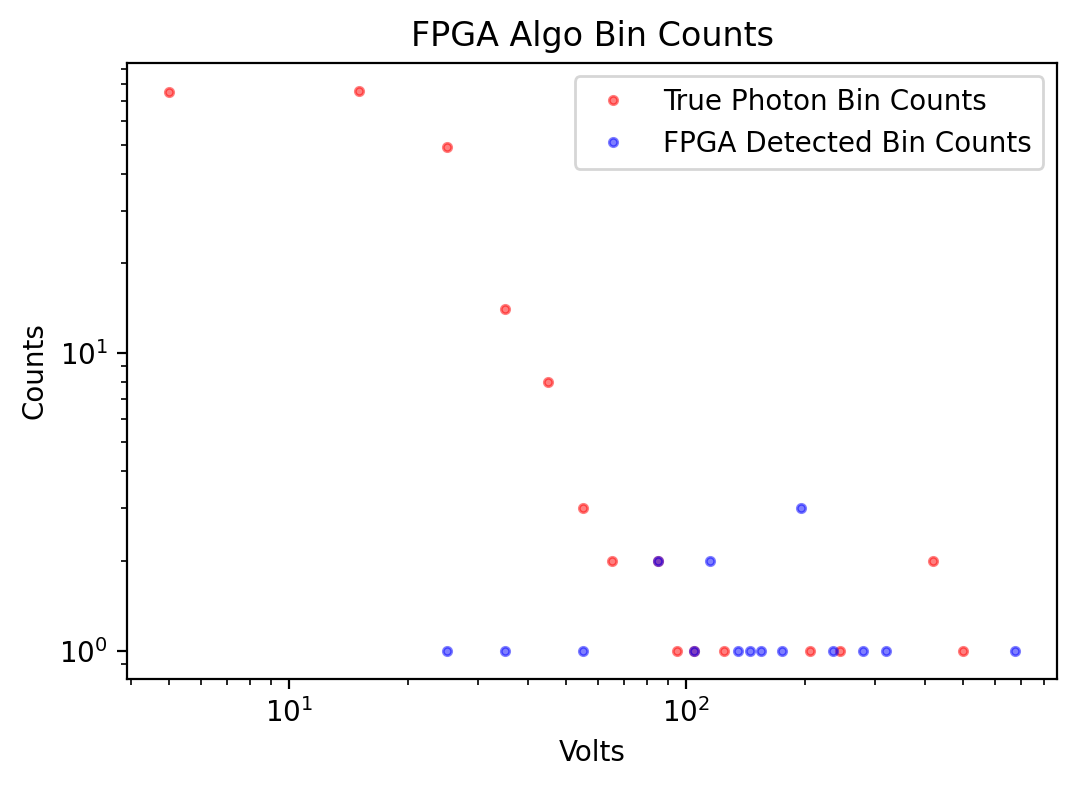

In [7]:
# FPGA Counting
thresh = 8.0  # units of mV  this is the pulse trigger threshold
int_i = 50  # integ.ration time = 1.25 microsecs = 50 samples at 40MHz sampling
dead_i = int_i  # deadtime = integration time
extend = 1  # extendable dead time parameter
escale = .63  # being used to scale the pulse integration value to energy in keV. experimentally determined.
baseline=0
energies, _ = trace_to_counts(trace, 0, dt, thresh, baseline, extend, escale, int_i, dead_i)
fpga_volts = np.array(energies) * mV_per_keV
_, _, counted_counts, _ = volts_counted_hist(volts_list, fpga_volts, bins=bins)

plt.figure(figsize=(6,4), dpi=200)
original_gt0 = np.where(original_counts > 0)[0]
counted_gt0 = np.where(counted_counts > 0)[0]
plt.plot(bins[:-1][original_gt0], original_counts[original_gt0], label='True Photon Bin Counts', linestyle='', marker='.', color='r', alpha =.5)
plt.plot(bins[:-1][counted_gt0], counted_counts[counted_gt0], label='FPGA Detected Bin Counts', linestyle='', marker='.', color='b', alpha =.5)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Volts')
plt.ylabel('Counts')
plt.title('FPGA Algo Bin Counts')
plt.legend()

# Detect Photons...
print('\nDetection:')
print('True Photons:', volts_list.size, 'Detected Photons:', fpga_volts.size)

photons_counted = photons_counted_pct(fpga_volts, volts_list)
energy_counted = volts_counted_pct(fpga_volts, volts_list)
print("Counted Photons: {:.2f}%, Counted Energy: {:.5f}%".format(photons_counted*100, energy_counted*100))

In [8]:
true_counts_by_bin = np.zeros((bins.size-1))
wiener_counts_by_bin = np.zeros((bins.size-1))
nnlsr_counts_by_bin = np.zeros((bins.size-1))
fpga_counts_by_bin = np.zeros((bins.size-1))

for i in range(repeat):
	trace, time_vector, true_volts_list, volts_time_index = spectrum_trace(
	count_rate_=countrate, dt_=dt, total_time_=total_time,
	pulse_=decimal_kernel, bin_energies_=bins, spectrum_=spectrum,
	mV_per_keV_=mV_per_keV, noise_std_=noise_stdev, baseline_=0,
	sampling_ratio_=1, discretize=True, bits_=bits,
	seed_=None, clip=False, debug=False)
		
	# Wiener Deconvolution Algorithm
	wiener_deconv = wiener_deconvolve(trace, decimal_kernel, K) * correction_factor
	# thresholded_volts_list, thresholded_indeces = threshold_listmode(wiener_deconv, threshold)
	peaks, _ = find_peaks(wiener_deconv, height=threshold)
	peak_vals = wiener_deconv[peaks]
	original_counts, _, wiener_counts, _ = volts_counted_hist(true_volts_list, peak_vals, bins=bins)
	true_counts_by_bin += original_counts
	wiener_counts_by_bin += wiener_counts
	
	# NNLSR Counting Algo
	nnlsr_deconv = td_nnlsr_deconvolve(trace, decimal_kernel)
	thresholded_volts_list, thresholded_indeces = threshold_listmode(nnlsr_deconv, threshold)
	_, _, nnlsr_counts, _ = volts_counted_hist(true_volts_list, thresholded_volts_list, bins=bins)
	nnlsr_counts_by_bin += nnlsr_counts
	
	# FPGA Counting Algo
	# thresh = 8.0  # units of mV  this is the pulse trigger threshold
	# int_i = 50  # integ.ration time = 1.25 microsecs = 50 samples at 40MHz sampling
	# dead_i = int_i  # deadtime = integration time
	# extend = 1  # extendable dead time parameter
	# escale = .63  # being used to scale the pulse integration value to energy in keV. experimentally determined.
	# baseline=0
	energies, _ = trace_to_counts(trace, 0, dt, thresh, baseline, extend, escale, int_i, dead_i)
	fpga_volts_list = np.array(energies)
	_, _, fpga_counts, _ = volts_counted_hist(true_volts_list, fpga_volts_list, bins=bins)
	fpga_counts_by_bin += fpga_counts
	
	print("{}/{}".format(i, repeat))


0/10
1/10
2/10
3/10
4/10
5/10
6/10
7/10
8/10
9/10


In [9]:
# Count Stats
true_energy = np.sum(true_counts_by_bin * bins[:-1])
nnlsr_energy = np.sum(nnlsr_counts_by_bin * bins[:-1])
wiener_energy = np.sum(wiener_counts_by_bin * bins[:-1])
fpga_energy = np.sum(fpga_counts_by_bin * bins[:-1])
# print(true_energy, nnlsr_energy, wiener_energy, fpga_energy)

nnlrs_acc = nnlsr_energy / true_energy
wiener_acc = wiener_energy / true_energy
fpga_acc = fpga_energy / true_energy
print('NNLSR, Wiener, FPGA algo accuracies:', nnlrs_acc, wiener_acc, fpga_acc)

nnlsr_error = (true_energy - nnlsr_energy) / true_energy
wiener_error = (true_energy - wiener_energy) / true_energy
fpga_error = (true_energy - fpga_energy) / true_energy
print('NNLSR, Wiener, FPGA algo errors:', nnlsr_error, wiener_error, fpga_error)


NNLSR, Wiener, FPGA algo accuracies: 0.9268797838811347 1.1110310670868977 2.940477262494372
NNLSR, Wiener, FPGA algo errors: 0.07312021611886538 -0.11103106708689779 -1.9404772624943718


128


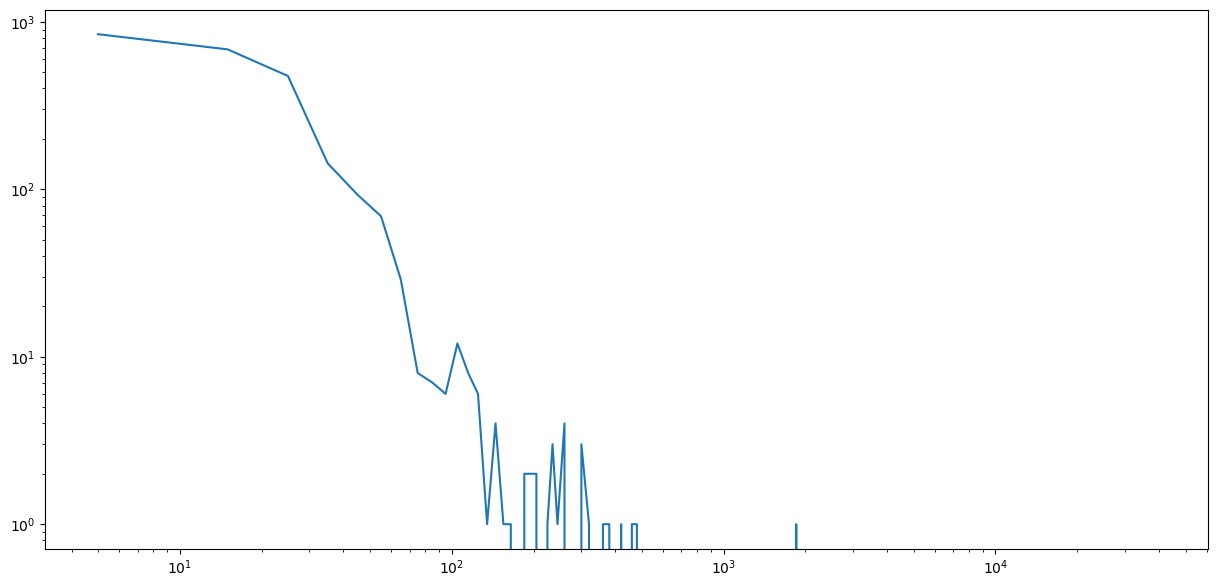

In [10]:
plt.figure()
print(true_counts_by_bin.size)
plt.plot(bins[:-1], true_counts_by_bin)
plt.xscale('log')
plt.yscale('log')

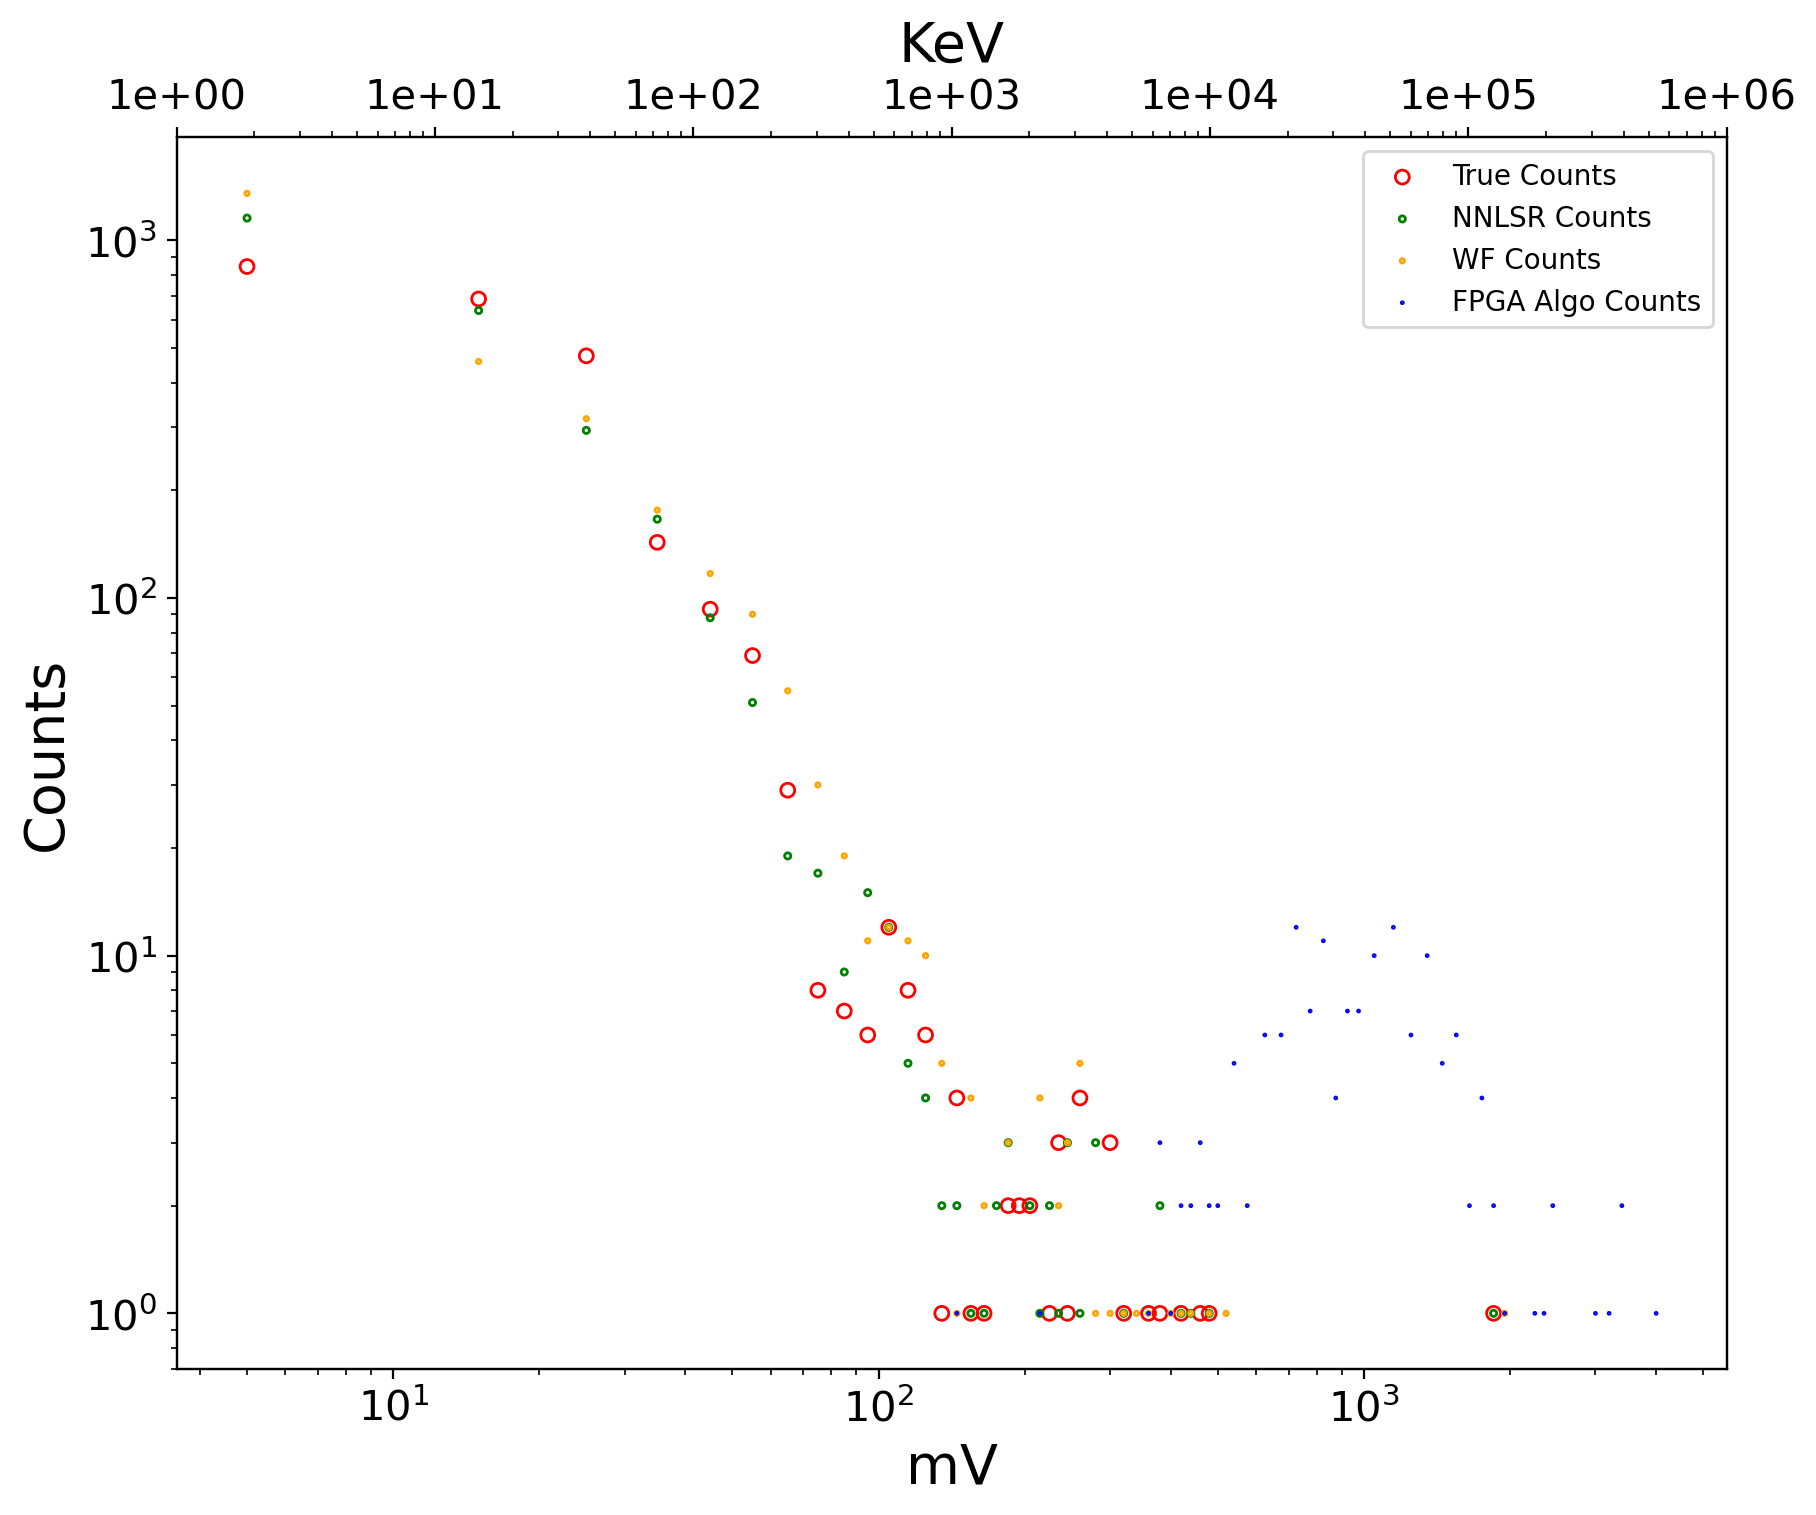

In [15]:
original_gt0 = np.where(true_counts_by_bin > 0)[0]
wiener_gt0 = np.where(wiener_counts_by_bin > 0)[0]
nnlsr_gt0 = np.where(nnlsr_counts_by_bin > 0)[0]
fpga_gt0 = np.where(fpga_counts_by_bin > 0)[0]

fig, axes = plt.subplots(1,1, figsize=(10,8), dpi=200)
plt.scatter(bins[:-1][original_gt0], true_counts_by_bin[original_gt0], label='True Counts',
          s=100, facecolors='none', marker='.', edgecolors='r', alpha =1)
plt.scatter(bins[:-1][nnlsr_gt0], nnlsr_counts_by_bin[nnlsr_gt0], label='NNLSR Counts',
         s=20, facecolors='none', marker='.', edgecolors='g', linewidths=1, alpha =1)
plt.scatter(bins[:-1][wiener_gt0], wiener_counts_by_bin[wiener_gt0], label='WF Counts',
         s=10, facecolors='none', marker='.', edgecolors='orange', alpha =1)
plt.scatter(bins[:-1][fpga_gt0], fpga_counts_by_bin[fpga_gt0], label='FPGA Algo Counts',
         s=2, facecolors='none', marker='.', edgecolors='b', linewidths=1, alpha =1)

plt.xscale('log')
plt.yscale('log')

size = 20
ticksize = 15
plt.xlabel('mV', fontsize=size)
plt.title('KeV', fontsize=size)
plt.ylabel('Counts', fontsize=size)
plt.legend()
plt.xticks(fontsize=ticksize)
plt.yticks(fontsize=ticksize)

top_y = axes.twiny()
top_y.set_xscale('log')
xlim = axes.get_xlim()

top_y.set_xlim(xlim)
ticks = np.array(axes.get_xticks())
ticks_kev = ticks / mV_per_keV

ticks_kev = np.log10(ticks_kev)
ticks_kev = 10 ** (np.round(ticks_kev))

top_y.set_xticks(ticks_kev)
strings = []
for num in ticks_kev:
	strings.append("{:0.0e}".format(num))
top_y.set_xticklabels(strings, fontsize=ticksize)
# plt.show()
plt.savefig('Method_Comparison_{}_Counts'.format(sensor_type))



In [16]:
divisor = repeat * total_time
true_countrate_by_bin = true_counts_by_bin / divisor
wiener_countrate_by_bin = wiener_counts_by_bin / divisor
nnlsr_countrate_by_bin = nnlsr_counts_by_bin / divisor
fpga_countrate_by_bin = fpga_counts_by_bin / divisor

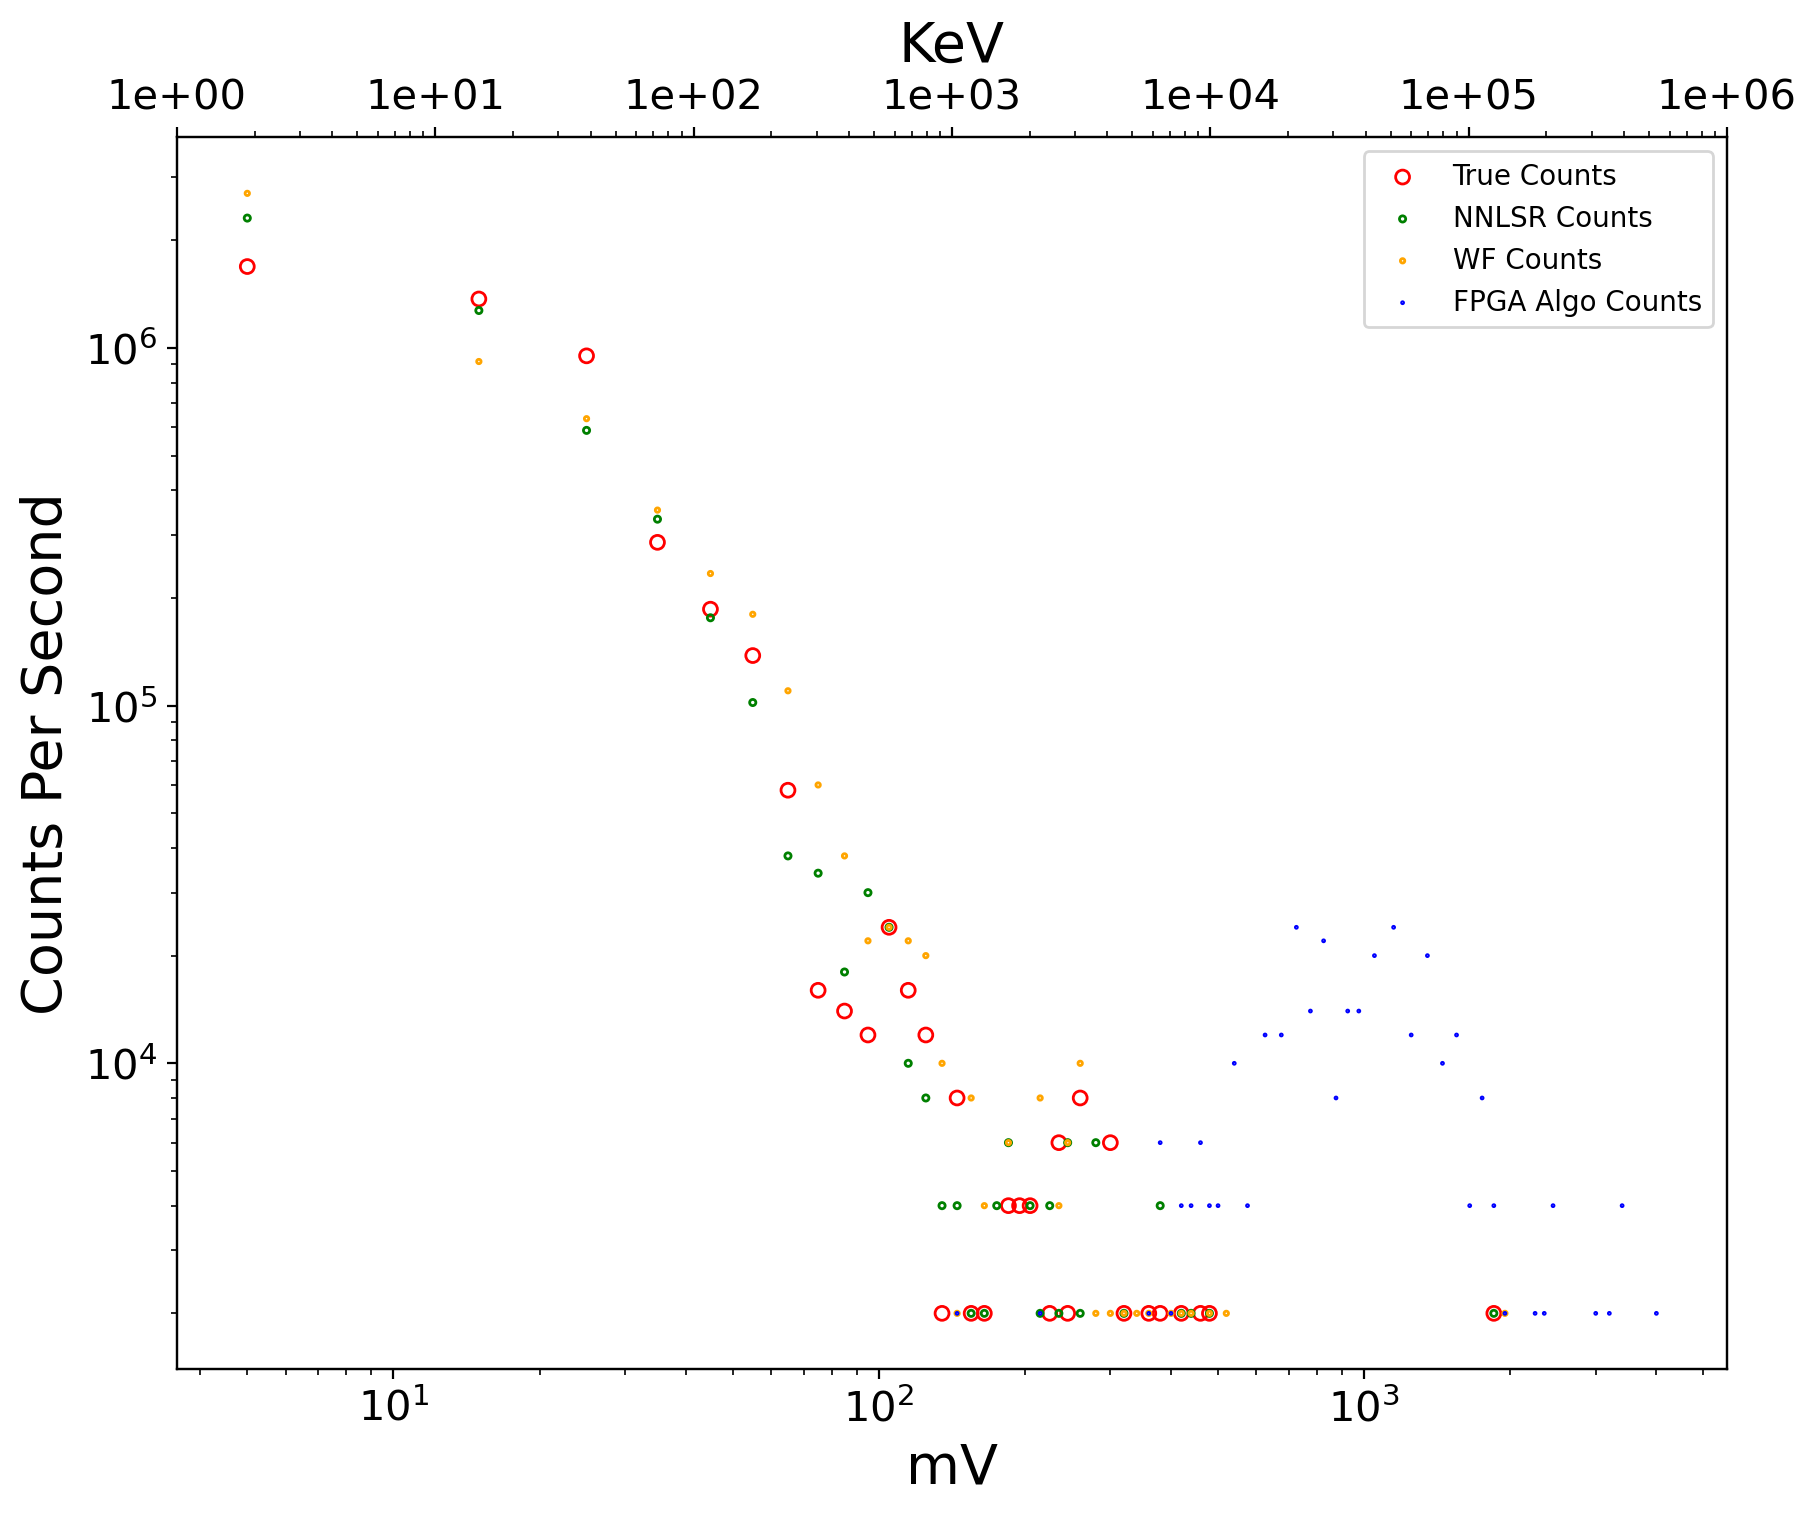

In [17]:
original_gt0 = np.where(true_countrate_by_bin > 0)[0]
wiener_gt0 = np.where(wiener_countrate_by_bin > 0)[0]
nnlsr_gt0 = np.where(nnlsr_countrate_by_bin > 0)[0]
fpga_gt0 = np.where(fpga_countrate_by_bin > 0)[0]

fig, axes = plt.subplots(1,1, figsize=(10,8), dpi=200)
plt.scatter(bins[:-1][original_gt0], true_countrate_by_bin[original_gt0], label='True Counts',
          s=100, facecolors='none', marker='.', edgecolors='r', alpha =1)
plt.scatter(bins[:-1][nnlsr_gt0], nnlsr_countrate_by_bin[nnlsr_gt0], label='NNLSR Counts',
         s=20, facecolors='none', marker='.', edgecolors='g', linewidths=1, alpha =1)
plt.scatter(bins[:-1][wiener_gt0], wiener_countrate_by_bin[wiener_gt0], label='WF Counts',
         s=10, facecolors='none', marker='.', edgecolors='orange', alpha =1)
plt.scatter(bins[:-1][fpga_gt0], fpga_countrate_by_bin[fpga_gt0], label='FPGA Algo Counts',
         s=2, facecolors='none', marker='.', edgecolors='b', linewidths=1, alpha =1)

plt.xscale('log')
plt.yscale('log')

size = 20
ticksize = 15
plt.xlabel('mV', fontsize=size)
plt.title('KeV', fontsize=size)
plt.ylabel('Counts Per Second', fontsize=size)
plt.legend()
plt.xticks(fontsize=ticksize)
plt.yticks(fontsize=ticksize)

top_y = axes.twiny()
top_y.set_xscale('log')
xlim = axes.get_xlim()

top_y.set_xlim(xlim)
ticks = np.array(axes.get_xticks())
ticks_kev = ticks / mV_per_keV
ticks_kev = np.log10(ticks_kev)
ticks_kev = 10 ** (np.round(ticks_kev))
top_y.set_xticks(ticks_kev)
strings = []
for num in ticks_kev:
	strings.append("{:0.0e}".format(num))
top_y.set_xticklabels(strings, fontsize=ticksize)
# plt.show()
plt.savefig('Method_Comparison_{}_rate'.format(sensor_type))


In [14]:
# # Try Multi-scale discretized kernels...
# gc.collect()
# 
# n_discrete = 2**bits
# n_kernel = 101
# _, disc_kernels = nai_pulse(1000, n_kernel, 1)
# disc_kernels = np.tile(disc_kernels, (n_discrete, 1)).T
# 
# for i in range(disc_kernels.shape[0]):
#     disc_kernels[:, i] = discretize(i/n_discrete * disc_kernels[:,i], bits)
#     
# 
# # fig, axes = plt.subplots(1, 1, figsize=(6, 4), dpi=400)
# # plot_index = (2 ** np.linspace(1, 6, 6)).astype(int)
# # for i in plot_index:
# #     axes.plot(disc_kernels[:,i], label=str(i))
# #     
# # axes.legend()
# # axes.set_title('Discretized Kernels at {} bits'.format(bits))
# # axes.set_xlabel('Index')
# # axes.set_ylabel('Discretized mV')
# 
# 
# # Generate A matrix...
# print(y.size, disc_kernels.shape)
# # Y=Trace, |Y|=M
# # X = photon energy matrix. |X|=N
# # Y=AX: Y[M] = A[M, b*N] X[b*N, M], b=2**bits n_discrete states...
# # Note dimms do not add up because this is an under-determined system...
# A = np.zeros((y.size, n_discrete*trace_fft_noise.size))
# print('Asize: {:.2E} Gb Array... {} {}'.format(8*A.size, A.shape, A.dtype))
# # A[:n_kernel, :n_discrete] = disc_kernels
# for i in range(0, y.size):
#     if i + n_kernel <= y.size:
#         r = np.roll(disc_kernels, i)
#         A[i:i+n_kernel, i*n_discrete:(i+1)*n_discrete] = r
#         # skip = 0
#         # print(i)
#     else:
#         r = np.roll(disc_kernels, i)
# 
#         # # End of A on time axis = beginning of r
#         # r_start = r.shape[0] - (y.size - i)  #r.shape[0] is time
#         # A[i:, i*n_discrete:(i+1)*n_discrete] = r[r_start:, :]
#         # 
#         # # Beginning of A on the time axis
#         # r_end = r_start - r.shape[0]
#         # A[:r.shape[0]+r_end, i*n_discrete:(i+1)*n_discrete] = r[:r_end, :]
#         # 
#         # # print(i, r_start, r_end)
#     
# # print(A.shape)
# # print(A[0:255, 255])
# # print()
# # print(A[0:255, 255*2])
# 
# x, resid = nnls(A, y)
# print(x.shape)
# 
